In [331]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings('ignore')

## Load and Prepare Data

In [332]:
df = pd.read_csv('C:\\Users\\ASUS\\Desktop\\data_sadeghiyeh2.csv')

In [333]:
df.head()

,Area,Year Of Construction,Room,Floor Number,Parking,Warehouse,Elevator,Price
0,70.0,1379.0,2.0,3.0,False,True,False,7.650000e+09
1,58.0,1401.0,2.0,2.0,True,True,True,3.240000e+09
2,91.0,1404.0,2.0,1.0,True,True,True,1.910000e+10
3,145.0,1398.0,3.0,1.0,True,True,True,3.200000e+10
4,55.0,1397.0,1.0,2.0,True,True,True,3.000000e+09


In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area                  298 non-null    float64
 1   Year Of Construction  298 non-null    float64
 2   Room                  298 non-null    float64
 3   Floor Number          314 non-null    float64
 4   Parking               320 non-null    bool   
 5   Warehouse             320 non-null    bool   
 6   Elevator              320 non-null    bool   
 7   Price                 318 non-null    float64
dtypes: bool(3), float64(5)
memory usage: 13.6 KB


In [335]:
print(df.shape)

(320, 8)


In [336]:

cols_to_int = ["Year Of Construction", "Room", "Floor Number"]

for col in cols_to_int:
    df[col] = (
        pd.to_numeric(df[col], errors="coerce")    
        .round()                                  
        .astype("Int64")                           
    )

In [337]:
print(df.duplicated().sum())

10


In [338]:
df['Price'].describe()

count    3.180000e+02
mean     1.442461e+11
std      1.611594e+12
min      1.000000e+03
25%      8.850000e+09
50%      1.630000e+10
75%      2.100000e+10
max      2.500000e+13
Name: Price, dtype: float64

In [339]:
df[df['Price'] > 1e11]

,Area,Year Of Construction,Room,Floor Number,Parking,Warehouse,Elevator,Price
57,NaN,<NA>,<NA>,366666000,False,False,False,1.100000e+11
60,113.0,1402,2,1,True,True,True,2.500000e+13
84,NaN,<NA>,<NA>,300000000,False,False,False,1.275000e+11
100,NaN,<NA>,<NA>,397222000,False,False,False,1.430000e+11
112,81.0,1397,2,1,True,True,True,1.430000e+13
136,NaN,<NA>,<NA>,619047000,False,False,False,2.600000e+11
180,NaN,<NA>,<NA>,576923000,True,False,False,2.400000e+11
237,NaN,<NA>,<NA>,336000000,False,False,False,1.260000e+11
256,NaN,<NA>,<NA>,802739000,False,False,False,2.930000e+11
275,NaN,<NA>,<NA>,351428000,False,False,False,1.230000e+11


In [340]:
df.sort_values(by='Price', ascending=False).head(10)

,Area,Year Of Construction,Room,Floor Number,Parking,Warehouse,Elevator,Price
60,113.0,1402,2,1,True,True,True,2.500000e+13
112,81.0,1397,2,1,True,True,True,1.430000e+13
256,NaN,<NA>,<NA>,802739000,False,False,False,2.930000e+11
136,NaN,<NA>,<NA>,619047000,False,False,False,2.600000e+11
180,NaN,<NA>,<NA>,576923000,True,False,False,2.400000e+11
300,NaN,<NA>,<NA>,309090000,False,False,False,1.700000e+11
100,NaN,<NA>,<NA>,397222000,False,False,False,1.430000e+11
84,NaN,<NA>,<NA>,300000000,False,False,False,1.275000e+11
237,NaN,<NA>,<NA>,336000000,False,False,False,1.260000e+11
275,NaN,<NA>,<NA>,351428000,False,False,False,1.230000e+11


In [341]:
df.sort_values(by='Area', ascending=False).head(10)

,Area,Year Of Construction,Room,Floor Number,Parking,Warehouse,Elevator,Price
216,607200.0,1380,1,1,False,False,False,7.200000e+09
33,450.0,1396,3,10000000,True,True,False,1.300000e+10
302,445.0,1370,0,5280000,True,True,False,2.350000e+09
95,300.0,1370,0,6000000,True,False,False,1.800000e+09
129,300.0,1404,3,6666000,True,True,False,2.000000e+09
18,300.0,1400,3,3,True,True,True,8.500000e+10
52,270.0,1404,0,5555000,True,False,False,1.500000e+09
69,200.0,1403,3,6000000,True,True,False,1.500000e+09
27,200.0,1402,3,5000000,True,True,False,2.000000e+09
117,178.0,1404,3,2,True,True,True,3.700000e+10


# Explore the data (EDA)

In [342]:
df.columns

Index(['Area', 'Year Of Construction', 'Room', 'Floor Number', 'Parking',
       'Warehouse', 'Elevator', 'Price'],
      dtype='object')

In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area                  298 non-null    float64
 1   Year Of Construction  298 non-null    Int64  
 2   Room                  298 non-null    Int64  
 3   Floor Number          314 non-null    Int64  
 4   Parking               320 non-null    bool   
 5   Warehouse             320 non-null    bool   
 6   Elevator              320 non-null    bool   
 7   Price                 318 non-null    float64
dtypes: Int64(3), bool(3), float64(2)
memory usage: 14.5 KB


In [344]:
df.describe()

,Area,Year Of Construction,Room,Floor Number,Price
count,298.000000,298.0,298.0,314.0,3.180000e+02
mean,2141.758389,1394.006711,2.067114,19114228.426752,1.442461e+11
std,35168.127665,10.325671,0.615889,89221645.59343,1.611594e+12
min,42.000000,1370.0,0.0,0.0,1.000000e+03
25%,78.000000,1385.0,2.0,2.0,8.850000e+09
50%,100.000000,1398.0,2.0,3.0,1.630000e+10
75%,120.000000,1403.0,2.0,4.0,2.100000e+10
max,607200.000000,1404.0,4.0,802739000.0,2.500000e+13


In [345]:

df["Area"] = pd.to_numeric(df["Area"] , errors='coerce')

In [346]:
df.shape

(320, 8)

In [347]:
print(df.dtypes)

Area                    float64
Year Of Construction      Int64
Room                      Int64
Floor Number              Int64
Parking                    bool
Warehouse                  bool
Elevator                   bool
Price                   float64
dtype: object


In [348]:
df.isnull().sum()

Area                    22
Year Of Construction    22
Room                    22
Floor Number             6
Parking                  0
Warehouse                0
Elevator                 0
Price                    2
dtype: int64

In [349]:
# I will drop missing values although it is not necessary because used models can manage missing values.
df.dropna(inplace=True)

In [350]:
df.shape

(292, 8)

In [351]:
df.isnull().sum()

Area                    0
Year Of Construction    0
Room                    0
Floor Number            0
Parking                 0
Warehouse               0
Elevator                0
Price                   0
dtype: int64

In [352]:
df[df['Area'] > 500]

,Area,Year Of Construction,Room,Floor Number,Parking,Warehouse,Elevator,Price
216,607200.0,1380,1,1,False,False,False,7.200000e+09


In [353]:
df = df[(df["Price"] >= 5e8) & (df["Price"] <= 5e10)]

In [354]:
df[df['Price'] > 1e11]

,Area,Year Of Construction,Room,Floor Number,Parking,Warehouse,Elevator,Price


In [355]:
df = df[
    (df["Year Of Construction"] >= 1404 - 100) &     
    (df["Room"] >= 1) & (df["Room"] < 7) &           
    (df["Floor Number"] >= 1) & (df["Floor Number"] < 40) &  
    (df["Area"] >= 30) & (df["Area"] <= 500) &       
    (df["Price"] >= 5e8) & (df["Price"] <= 5e10)     
]

In [356]:
print(df['Price'].describe())
print(df.shape)

count    2.690000e+02
mean     1.572045e+10
std      8.431459e+09
min      1.700000e+09
25%      1.030000e+10
50%      1.640000e+10
75%      2.050000e+10
max      4.150000e+10
Name: Price, dtype: float64
(269, 8)


In [357]:
df["building_age"] = 1404 - df["Year Of Construction"]
df["has_elevator"] = df["Elevator"].astype(int)
df["has_parking"] = df["Parking"].astype(int)

In [358]:
df["Year Of Construction"] = pd.to_numeric(
    df["Year Of Construction"],
    errors="coerce"
).round().astype("Int64")

In [359]:
df.describe()

,Area,Year Of Construction,Room,Floor Number,Price,building_age,has_elevator,has_parking
count,269.000000,269.0,269.0,269.0,2.690000e+02,269.0,269.000000,269.000000
mean,97.602230,1394.115242,2.066914,2.650558,1.572045e+10,9.884758,0.754647,0.910781
std,28.893166,10.131123,0.555822,1.434064,8.431459e+09,10.131123,0.431098,0.285591
min,42.000000,1370.0,1.0,1.0,1.700000e+09,0.0,0.000000,0.000000
25%,73.000000,1385.0,2.0,2.0,1.030000e+10,1.0,1.000000,1.000000
50%,97.000000,1398.0,2.0,2.0,1.640000e+10,6.0,1.000000,1.000000
75%,115.000000,1403.0,2.0,3.0,2.050000e+10,19.0,1.000000,1.000000
max,178.000000,1404.0,3.0,12.0,4.150000e+10,34.0,1.000000,1.000000


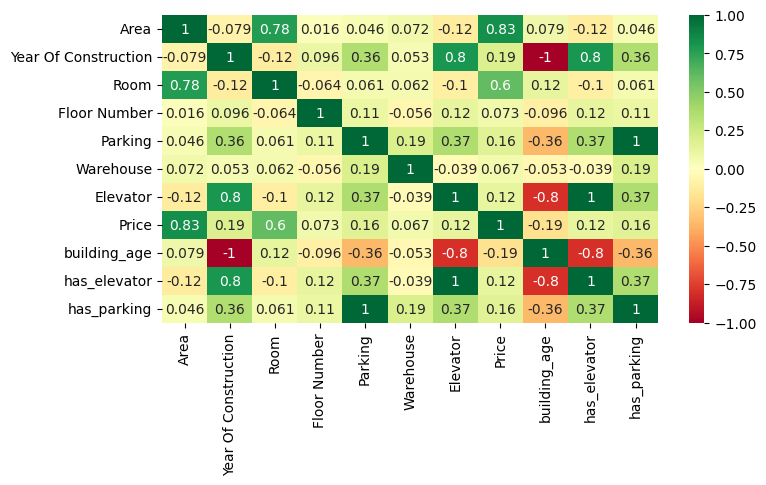

In [360]:

plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.show()

In [361]:
df['log_price'] = np.log(df['Price'])

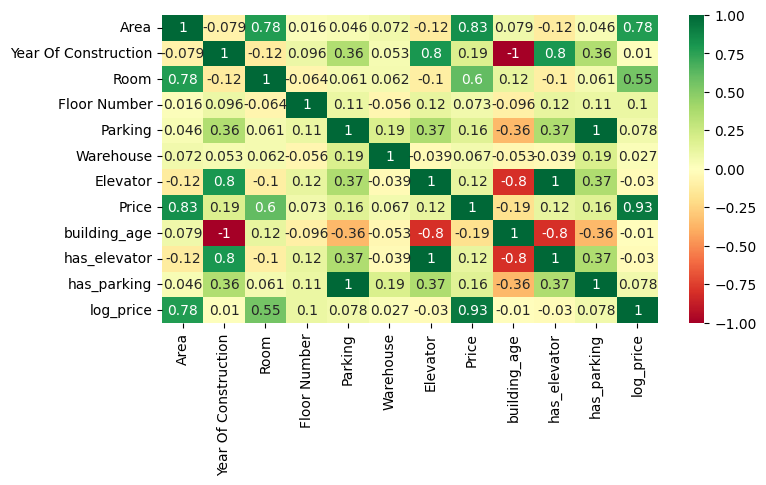

In [362]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.show()

In [363]:
import numpy as np

df["log_price"] = np.log(df["Price"])

print("corr(Area, Price)     =", df["Area"].corr(df["Price"]))
print("corr(Area, log_price) =", df["Area"].corr(df["log_price"]))
print("corr(log_price, Price)=", df["log_price"].corr(df["Price"]))

df["price_per_m2"] = df["Price"] / df["Area"]
print("corr(log_price, price_per_m2) =", df["log_price"].corr(df["price_per_m2"]))

corr(Area, Price)     = 0.8291140356786375
corr(Area, log_price) = 0.7803805459025777
corr(log_price, Price)= 0.928351873304652
corr(log_price, price_per_m2) = 0.8615611978541629


In [364]:
print(df["price_per_m2"].describe())
print(df["price_per_m2"].std())

count    2.690000e+02
mean     1.530178e+08
std      6.151586e+07
min      3.035714e+07
25%      1.148551e+08
50%      1.623596e+08
75%      1.980952e+08
max      5.545455e+08
Name: price_per_m2, dtype: float64
61515862.16870724


In [365]:
df_2room = df[df["Room"] == 2]
df_3room = df[df["Room"] == 3]

print(df_2room["Area"].corr(df_2room["Price"]))
print(df_3room["Area"].corr(df_3room["Price"]))

0.8105756967144502
0.5719937618938767


<Axes: xlabel='Area', ylabel='Price'>

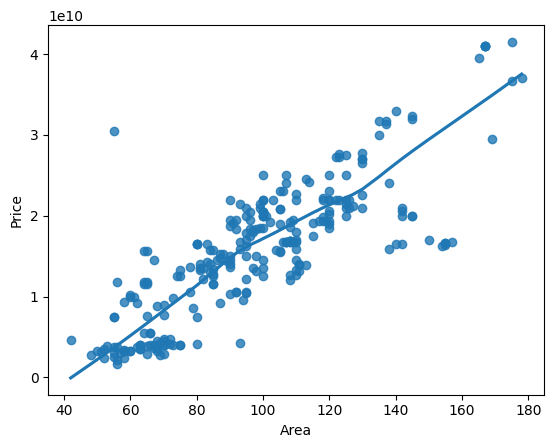

In [366]:
import seaborn as sns
sns.regplot(x='Area', y='Price', data=df, lowess=True)

In [367]:
pd.crosstab( df.Parking, df.Room )

Room,1,2,3
Parking,,,
False,6,13,5
True,27,172,46


In [368]:
df[ df.Area <= 85 ]["Parking"].value_counts( )

Parking
True     85
False    12
Name: count, dtype: int64

In [369]:
room_parking_room_mean_df = df.groupby( ['Room','Parking'] )['Price'].mean().reset_index()
room_parking_room_mean_df

,Room,Parking,Price
0,1,False,8.445000e+09
1,1,True,7.427037e+09
2,2,False,1.075077e+10
3,2,True,1.480576e+10
4,3,False,1.654000e+10
5,3,True,2.627283e+10


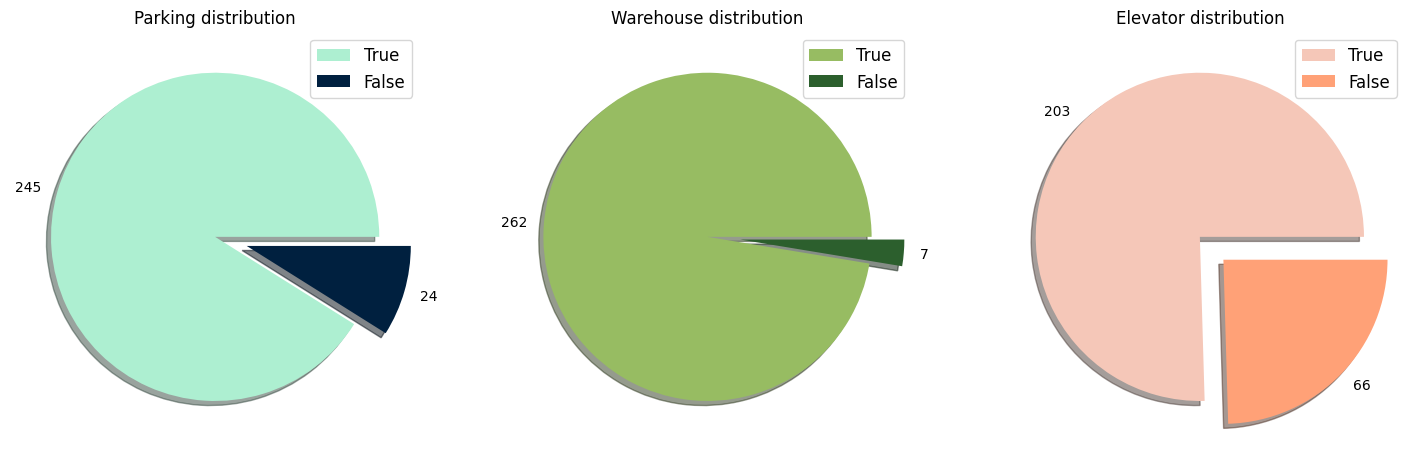

In [370]:
fig, ax = plt.subplots(ncols=3, figsize=(18,6))

colors = [['#ADEFD1FF', '#00203FFF'], ['#97BC62FF', '#2C5F2D'], ['#F5C7B8FF', '#FFA177FF']]
explode = [0, 0.2]
columns = ['Parking', 'Warehouse', 'Elevator']
for i in range(3):
        data = df[columns[i]].value_counts()
        ax[i].pie(data, labels=data.values, explode=explode, colors=colors[i], shadow=True)
        ax[i].legend(labels=data.index, fontsize='large')
        ax[i].set_title('{} distribution'.format(columns[i]))

In [371]:
df.columns

Index(['Area', 'Year Of Construction', 'Room', 'Floor Number', 'Parking',
       'Warehouse', 'Elevator', 'Price', 'building_age', 'has_elevator',
       'has_parking', 'log_price', 'price_per_m2'],
      dtype='object')

In [372]:
X = df.drop(columns=["Price", "log_price"])
y = df["log_price"]

In [373]:
import numpy as np


df = df.drop(columns=["price_per_m2"], errors="ignore")
df["building_age"] = 1404 - df["Year Of Construction"]
df["log_price"] = np.log1p(df["Price"])
X = df.drop(columns=["Price", "log_price", "Year Of Construction"])
y = df["log_price"]

In [374]:
num_cols = X.select_dtypes(include=["number"]).columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

In [375]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

In [376]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe, X, y,
        cv=kf,
        scoring=["neg_mean_absolute_error", "r2"]
    )
    
    results[name] = {
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "R2": scores["test_r2"].mean()
    }

for model, metrics in results.items():
    print(model, metrics)

Ridge {'MAE': np.float64(0.3611426466774989), 'R2': np.float64(0.5599585941868693)}
Lasso {'MAE': np.float64(0.36105164418342983), 'R2': np.float64(0.5602847032801934)}
RandomForest {'MAE': np.float64(0.16649941387529682), 'R2': np.float64(0.7691832076900058)}
GradientBoosting {'MAE': np.float64(0.20221159372968428), 'R2': np.float64(0.6315694097698221)}
SVR {'MAE': np.float64(0.1861614782489623), 'R2': np.float64(0.7958783474595964)}
KNN {'MAE': np.float64(0.18842652467445015), 'R2': np.float64(0.7787020022576239)}


In [377]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error

pred_log = cross_val_predict(pipe, X, y, cv=5)

pred_price = np.expm1(pred_log)
real_price = np.expm1(y)

mae = mean_absolute_error(real_price, pred_price)
print("CV MAE:", mae)

CV MAE: 2284047109.123878


In [378]:

from sklearn.model_selection import KFold, cross_validate
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=kf,
        scoring=["neg_mean_absolute_error", "r2"],
        return_train_score=False
    )
    
    results.append({
        "Model": name,
        "MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
        "MAE_std": scores["test_neg_mean_absolute_error"].std(),
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std()
    })

results_df = pd.DataFrame(results).sort_values("R2_mean", ascending=False)

print(results_df)

              Model  MAE_mean   MAE_std   R2_mean    R2_std
4               SVR  0.186161  0.019690  0.795878  0.098530
5               KNN  0.188427  0.022135  0.778702  0.088623
2      RandomForest  0.166499  0.028215  0.769183  0.128734
3  GradientBoosting  0.202212  0.056201  0.631569  0.232865
1             Lasso  0.361052  0.007986  0.560285  0.118387
0             Ridge  0.361143  0.008519  0.559959  0.117917


In [379]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2_mean", ascending=False)

print(results_df)

              Model  MAE_mean   MAE_std   R2_mean    R2_std
4               SVR  0.186161  0.019690  0.795878  0.098530
5               KNN  0.188427  0.022135  0.778702  0.088623
2      RandomForest  0.166499  0.028215  0.769183  0.128734
3  GradientBoosting  0.202212  0.056201  0.631569  0.232865
1             Lasso  0.361052  0.007986  0.560285  0.118387
0             Ridge  0.361143  0.008519  0.559959  0.117917


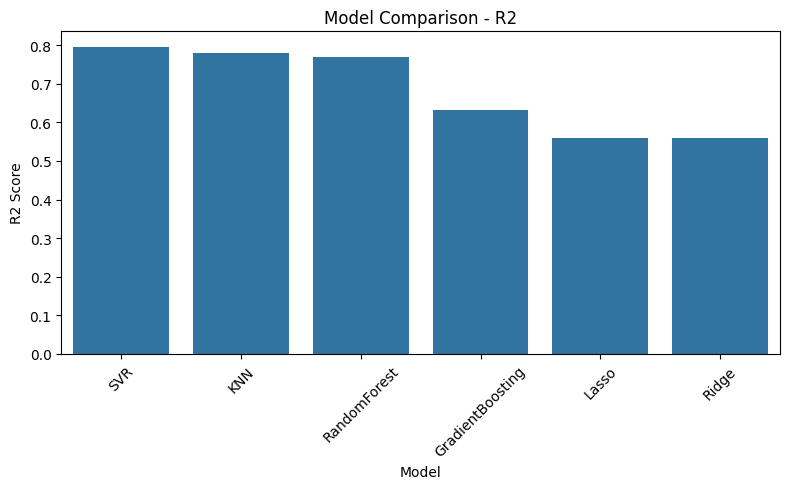

In [380]:

import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2_mean"
)

plt.ylabel("R2 Score")
plt.title("Model Comparison - R2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

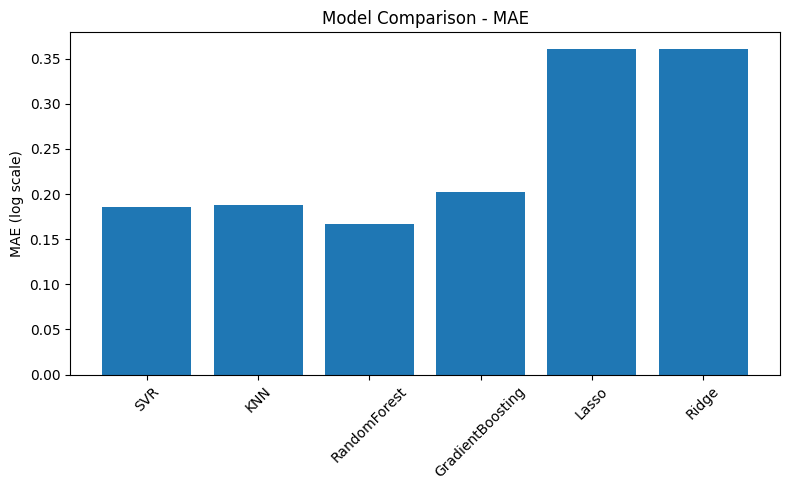

In [381]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["MAE_mean"])

plt.ylabel("MAE (log scale)")
plt.title("Model Comparison - MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

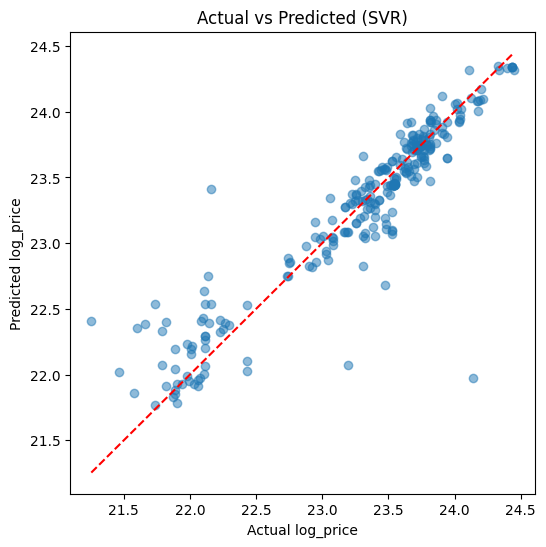

In [382]:

best_name = results_df.iloc[0]["Model"]

best_model = Pipeline([
    ("prep", preprocessor),
    ("model", models[best_name])
])

best_model.fit(X, y)

y_pred = best_model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Actual log_price")
plt.ylabel("Predicted log_price")
plt.title(f"Actual vs Predicted ({best_name})")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

In [383]:
import joblib

best_name = results_df.iloc[0]["Model"]

best_model = Pipeline([
    ("prep", preprocessor),
    ("model", models[best_name])
])

best_model.fit(X, y)

joblib.dump(best_model, "house_price_model.pkl")

print("Model saved successfully:", best_name)

Model saved successfully: SVR
